[dataset](https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records) from UCI repo

In [5]:
import pandas as pd
import numpy as np
from scipy.io import arff
import warnings
warnings.filterwarnings(action='ignore')
# 데이터 전처리
from sklearn.model_selection import train_test_split

# 모델 패키지
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# 모델 평가
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

matplotlib.rcParams['axes.unicode_minus'] = False
plt.rc('font', family='applegothic')

In [9]:
# red 
data = pd.read_csv("/Users/basamg/Project_kw/2025_2/ai_app/anomaly_detect/data/wine+quality/winequality-red.csv",sep=';')

# white 

#data=pd.read_csv("/Users/basamg/Project_kw/2025_2/ai_app/anomaly_detect/data/wine+quality/winequality-white.csv", sep=';')

# arff dataset load
file_path = '/Users/basamg/Project_kw/2025_2/ai_app/anomaly_detect/data/bank-additional-ful-nominal.arff'

try:
    data, meta_data = arff.loadarff(file_path)
    data = pd.DataFrame(data)
    for col in data.select_dtypes(['object']).columns: # 2진수 decode 필수
        data[col] = data[col].str.decode('utf-8')

except FileNotFoundError as e:
    print(e)
except Exception as e:
    print(e)

In [10]:
print("data 갯수 :\t",len(data))
print("feature 갯수 :\t", len(data.columns))
data.head()

data 갯수 :	 1599
feature 갯수 :	 12


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [11]:
data_modi = data.copy()
x = data_modi[data_modi.columns.difference(['quality'])]
y = data_modi['quality']

y[y<=6] = 0
y[y>6] =1

data_modi['quality'] = y
#over_sampled_x , over_sampled_y = bsm.fit_resample(X=x, y=y)

In [12]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [13]:
# for heart disease data
# wine quality score for 0 to 10
print(data['quality'].value_counts())

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


In [7]:
data.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

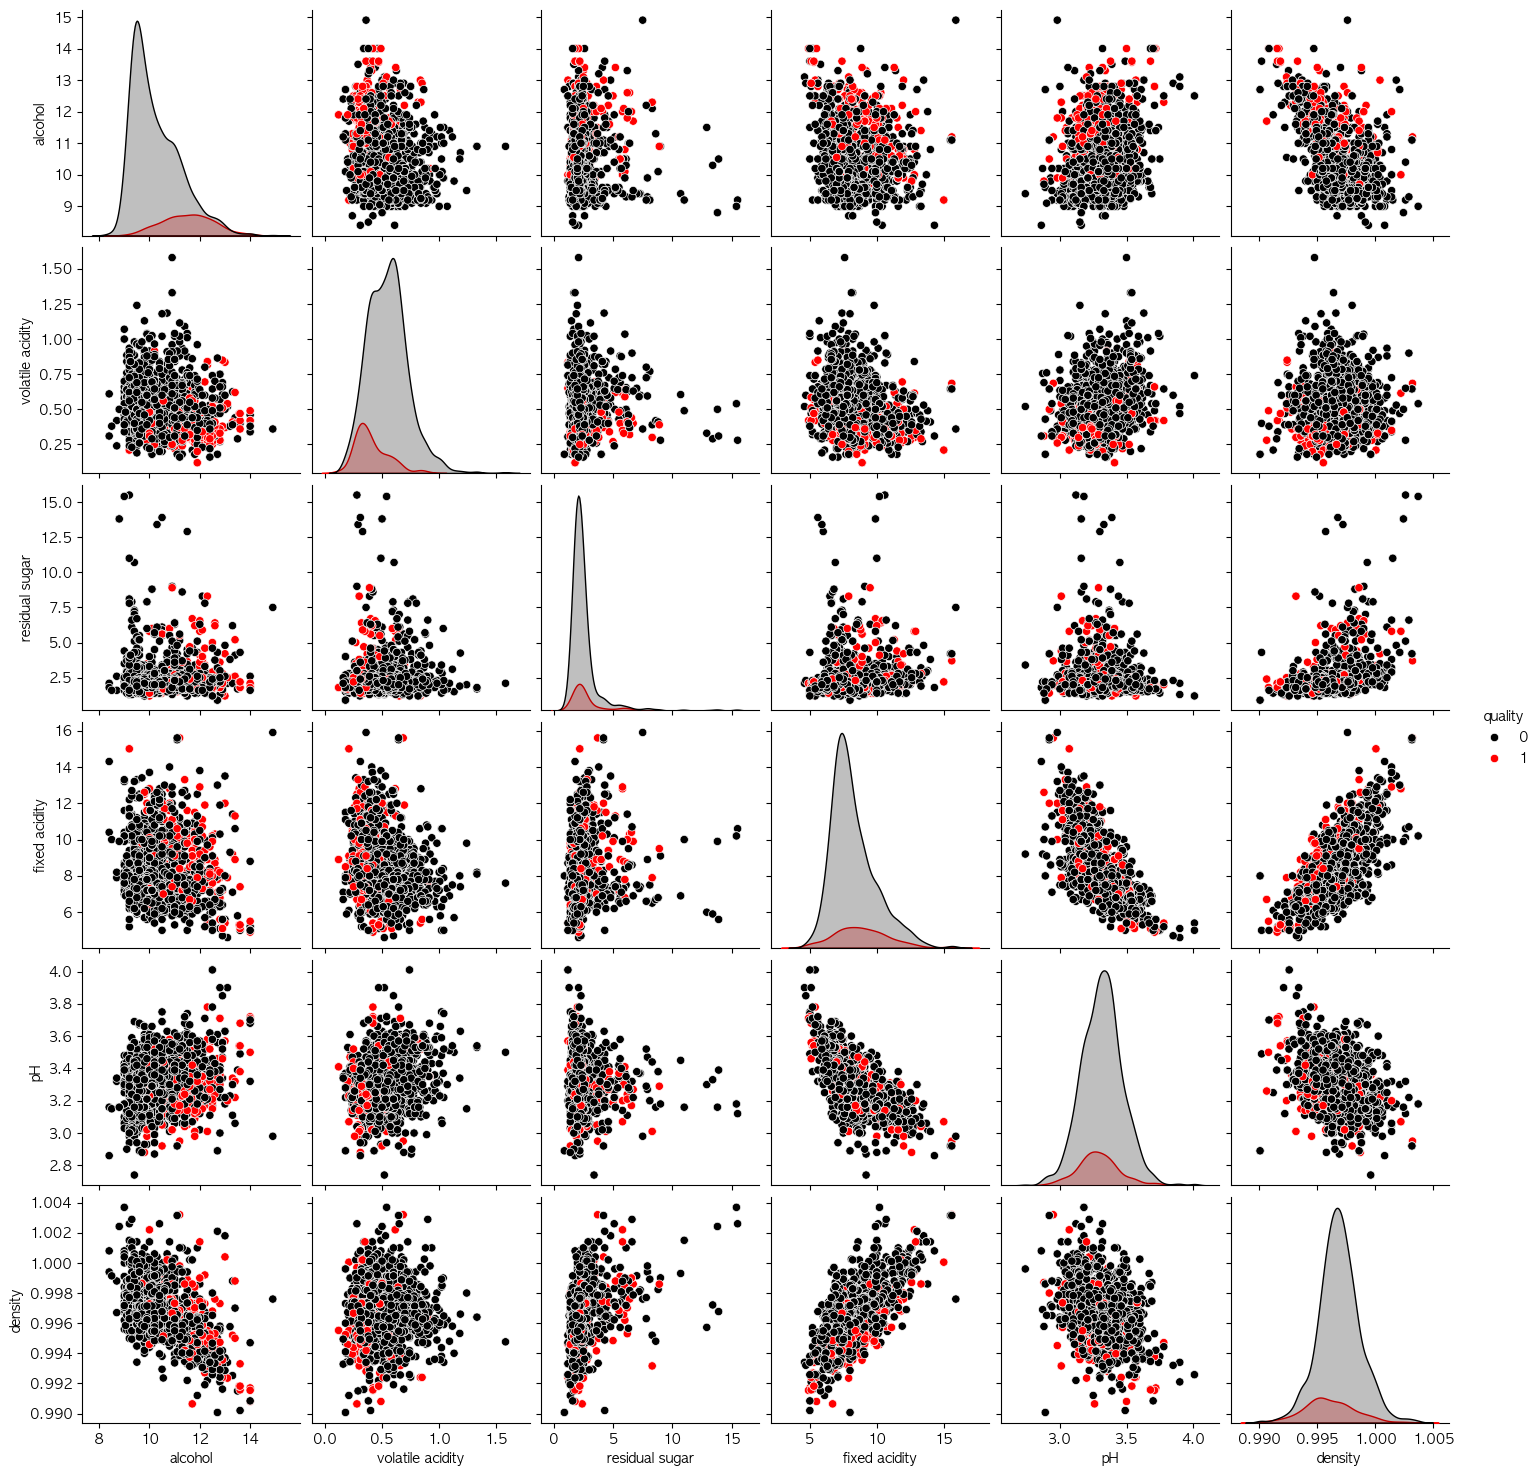

In [8]:
data_plot = data_modi.copy()

# 긍정적 이상치 탐지에 중요한 변수만 선택 (예시)
# 11개 전체 변수 대신, EDA에서 상관관계가 높았던 5~6개 변수만 선택하는 것이 효율적입니다.
key_features = ['alcohol', 'volatile acidity', 'residual sugar', 'fixed acidity', 'pH', 'density']
else_features = data_plot.columns.difference(key_features)
# Pair Plot 생성
sns.pairplot(
    data_plot, 
    vars=key_features, # 시각화할 특징 변수 리스트
    hue='quality', # '긍정적 이상치' 그룹으로 색상 구분
    palette={0: 'black', 1: 'red'}, # 색상 지정 (저품질: 검은색, 고품질: 빨간색)
    diag_kind='kde' # 대각선에는 분포 대신 밀도 플롯 사용
)
plt.show()

In [9]:
data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [10]:
data.mean()

fixed acidity            8.319637
volatile acidity         0.527821
citric acid              0.270976
residual sugar           2.538806
chlorides                0.087467
free sulfur dioxide     15.874922
total sulfur dioxide    46.467792
density                  0.996747
pH                       3.311113
sulphates                0.658149
alcohol                 10.422983
quality                  5.636023
dtype: float64

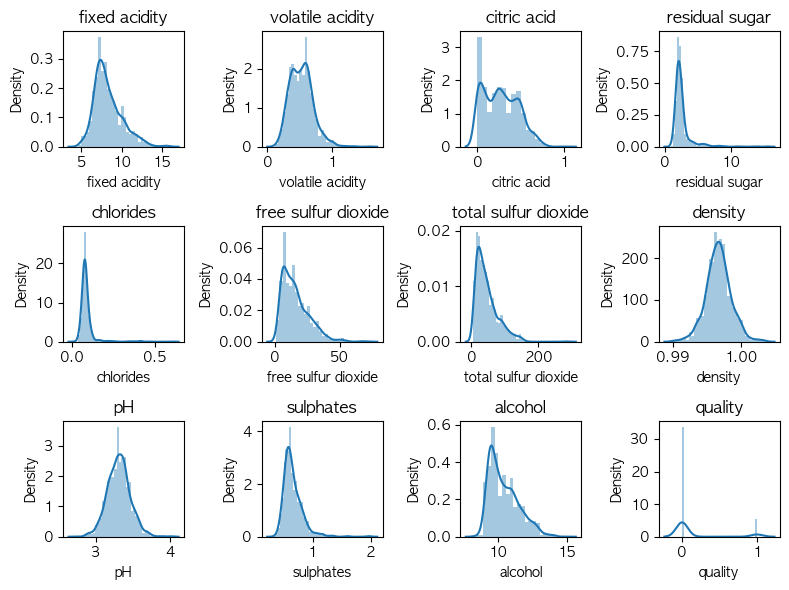

In [11]:
plt.figure(figsize=(8,6))
i = 0
for col in data_modi:
    i += 1
    plt.subplot(3,4,i)
    sns.distplot(data_modi.loc[data[col].notnull(), col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [12]:
print(target.value_counts())
plt.title("class distribution")
sns.countplot(y=data_modi['quality'], data=data_modi, palette=['blue','red'])

NameError: name 'target' is not defined

# Ouilier Detector Eval

ROC-AUC curve
- ROC : threshold,
- 이상•정상 을 탐지하는 모델이 threshold가 0~1 변화하며 TPR, FPR 이 어떻게 나타나는지를 본다

AUC score 가 1에 가까울수록 좋은 모델 (AUC : roc-auc 커브의 아랫 면적)
- AUC 가 크려면?
    - FPR 이 작을때, TPR 이 커야한다.
    - FPR = False Positive Rate : 양성으로 잘못 예측한 비율 = 실제 음성 중 양성으로 예측한 비율
    - TPR = True Positive Rate : 양성으로 잘 맞춘 비율 = 실제 양성 중, 양성이라고 예측한 비율

EER (Equal Error Rate)
- FAR (False Acceptance Rate) 과 FRR (False Rejectance Rate) 이 같아지는 지점
- EER 이 작을 수록 안정적인 분류 모델 

---
- FAR = FPR
- FRR = FNR 
- from [stackexchange](https://stats.stackexchange.com/questions/272962/are-far-and-frr-the-same-as-fpr-and-fnr-respectively)
---
EER 는 FAR, FRR 이 같아지는 지점
- FAR = FPR (O)
- FRR = FNR : 실제 양성인데 음성이라고 잘못 판단한 비율 → $1 - FRR = TPR$
---
brentq 함수
- Scipy 모듈에서 제공하는 함수
- 함수의 근을 찾는 알고리즘
- 근이 존재할 것 같은 구간을 함께 넣어줌

FAR = FPR → FAR - FPR = 0 → 

In [8]:
# about interp1d
# - x 에 대해서 입력 받고 보간 작업을 통해서 입력받는 x 에 대한 y 값 예측
# interp2d
# - x,y 를 입력받고 보간작업을 통해서 z 좌표를 예측

from scipy.interpolate import interp1d
from scipy.interpolate import interp2d
print(interp1d([1,2,5,7,9],[4,5,6,10,13])(9)) 
print(interp2d([1,2,5,7,9],[4,5,6,10,13],[1,2,3,4,5])(9,1)) 

13.0
[4.03631532]


In [14]:
# brentq example
# - 함수의 근을 찾아내는 역할, lambda 함수를 넣어주거나 func=x*2+1 이런식으로 넣어주는 방식

from scipy.optimize import brentq
brentq(lambda x : x*x -2, 0, 2)
# x^2 -2 = 0 에 대한 근을 찾는데, 예상되는 x의 범위를 0~2 사이로 입력해준다.

1.4142135623731364

EER : TAR 이랑 FRR 이 같아지는 지점

In [14]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from scipy.optimize import brentq
from scipy.interpolate import interp1d

def score(y_true:np.ndarray, y_pred:np.ndarray):
    FPR, TPR, threshold = roc_curve(y_true, y_pred, pos_label=1) # False Positive, True Positive
    FRR = 1 - TPR
    FAR = FPR
    EER = brentq(lambda x: 1. -x - interp1d(FPR, TPR)(x), 0., 1.)
    print(f"EER : {EER:.4f}")
    def plot():
        plt.plot(FPR, TPR, label="error trade off curve FAR vs FRR")
        plt.plot([0,1], [0,1], 'r--', label="random Classifier (FAR = FRR)")
        plt.scatter(EER,EER, color='blue', s=100, zorder=5)
        plt.annotate(
            f"EER: {EER:.4f}",
            xy=(EER,EER),
            xytext=(EER +0.1, EER+0.1),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5)
        )
        plt.legend()
        plt.xlim(0,1)
        plt.ylim(0,1)
        plt.gca().set_aspect('equal', adjustable='box')
        plt.show()
    plot()

        

# ~~borderline smote 기법을 이용한 Oversampling~~
# ~~smote 기법~~

In [10]:
from imblearn.over_sampling import BorderlineSMOTE, SMOTE


bsm = BorderlineSMOTE(random_state=42, kind="borderline-1")
sm = SMOTE(random_state=42)

<Axes: xlabel='fixed acidity', ylabel='volatile acidity'>

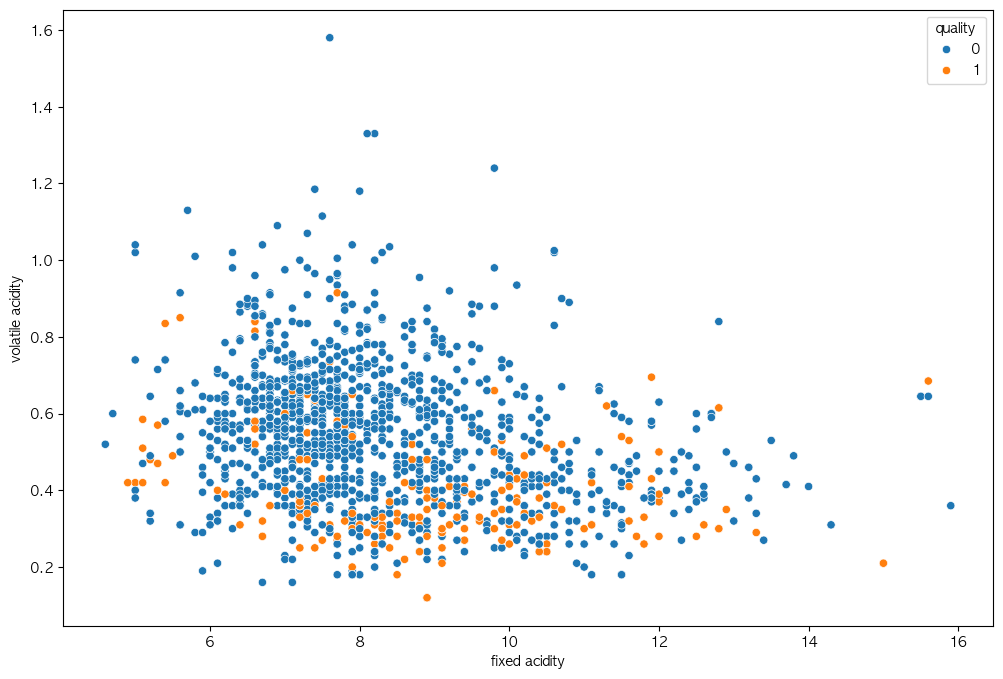

In [11]:
plt.figure(figsize=(12,8))
sns.scatterplot(x='fixed acidity', y='volatile acidity', hue=y, data=x)

In [12]:
over_sampled_x , over_sampled_y = sm.fit_resample(x,y)

In [15]:
# # Unused because Borderline SMOTE is any longer being used

x_train, x_test, y_train, y_test = train_test_split(over_sampled_x,over_sampled_y, test_size=0.2, random_state=42)
len(x_test)

NameError: name 'over_sampled_x' is not defined

In [14]:
y_test.value_counts()

quality
0    291
1    262
Name: count, dtype: int64

In [33]:
y.value_counts()

quality
0    1382
1     217
Name: count, dtype: int64

In [25]:
# 명목형 변수 : anaemia diabetes high_blood_pressure serum_creatinine sex smoking - 0 or 1
# time : follow-up perioud
x

,alcohol,chlorides,citric acid,density,fixed acidity,free sulfur dioxide,pH,residual sugar,sulphates,total sulfur dioxide,volatile acidity
0,9.4,0.076,0.00,0.99780,7.4,11.0,3.51,1.9,0.56,34.0,0.700
1,9.8,0.098,0.00,0.99680,7.8,25.0,3.20,2.6,0.68,67.0,0.880
2,9.8,0.092,0.04,0.99700,7.8,15.0,3.26,2.3,0.65,54.0,0.760
3,9.8,0.075,0.56,0.99800,11.2,17.0,3.16,1.9,0.58,60.0,0.280
4,9.4,0.076,0.00,0.99780,7.4,11.0,3.51,1.9,0.56,34.0,0.700
...,...,...,...,...,...,...,...,...,...,...,...
1594,10.5,0.090,0.08,0.99490,6.2,32.0,3.45,2.0,0.58,44.0,0.600
1595,11.2,0.062,0.10,0.99512,5.9,39.0,3.52,2.2,0.76,51.0,0.550
1596,11.0,0.076,0.13,0.99574,6.3,29.0,3.42,2.3,0.75,40.0,0.510
1597,10.2,0.075,0.12,0.99547,5.9,32.0,3.57,2.0,0.71,44.0,0.645


In [26]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1594    0
1595    0
1596    0
1597    0
1598    0
Name: quality, Length: 1599, dtype: int64

# for running code below convenient

In [16]:
# To Avoid modifying downstream code, Just assign original x, y  to over_sample_x(y) variable

x = data_modi[data_modi.columns.difference(['quality'])]
y = data_modi['quality']

over_sampled_x = x
over_sampled_y = y

In [17]:
over_sampled_y.value_counts()

quality
0    1382
1     217
Name: count, dtype: int64

In [18]:
from sklearn.preprocessing import StandardScaler

sc= StandardScaler()
x_train, x_test, y_train, y_test = train_test_split(over_sampled_x ,over_sampled_y, test_size=0.2, random_state=42)

x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

x_test_sc = pd.DataFrame(x_test_sc,columns=x.columns)
x_train_sc = pd.DataFrame(x_train_sc,columns=x.columns)

In [19]:
y_test.value_counts()

quality
0    273
1     47
Name: count, dtype: int64

# PCA
- std 가 큰 변수에 영향을 받는다 → scaling

In [261]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(x_train_sc)

PCA_pred_train = pca.transform(x_train_sc)
result = pca.transform(x_test_sc)
print(pca.explained_variance_ratio_)
result =pd.DataFrame(result, columns=['feature1', 'feature2'])

[0.2801769  0.17563995]


In [262]:
result

,feature1,feature2
0,-0.202257,0.568473
1,-1.002544,1.381198
2,1.812686,0.633669
3,0.208948,1.169311
4,-1.348497,-0.585962
...,...,...
315,-1.860115,-0.167971
316,-1.293796,3.298798
317,0.172793,-0.129364
318,0.854692,-1.219958


In [263]:
y_train.value_counts()

quality
0    1109
1     170
Name: count, dtype: int64

In [264]:
y_test.value_counts()

quality
0    273
1     47
Name: count, dtype: int64

In [265]:
y_test_reset_index = y_test.reset_index(drop=True)
y_test_reset_index

0      0
1      0
2      0
3      0
4      0
      ..
315    0
316    0
317    0
318    0
319    0
Name: quality, Length: 320, dtype: int64

In [266]:
result['label'] = y_test_reset_index
result

,feature1,feature2,label
0,-0.202257,0.568473,0
1,-1.002544,1.381198,0
2,1.812686,0.633669,0
3,0.208948,1.169311,0
4,-1.348497,-0.585962,0
...,...,...,...
315,-1.860115,-0.167971,0
316,-1.293796,3.298798,0
317,0.172793,-0.129364,0
318,0.854692,-1.219958,0


In [267]:
result

,feature1,feature2,label
0,-0.202257,0.568473,0
1,-1.002544,1.381198,0
2,1.812686,0.633669,0
3,0.208948,1.169311,0
4,-1.348497,-0.585962,0
...,...,...,...
315,-1.860115,-0.167971,0
316,-1.293796,3.298798,0
317,0.172793,-0.129364,0
318,0.854692,-1.219958,0


In [268]:
result['label'].unique()

array([0, 1])

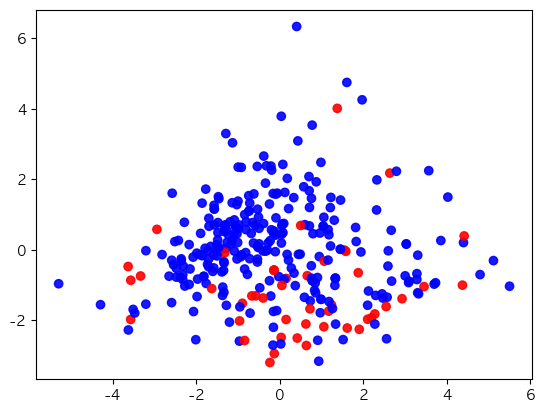

In [269]:
color_map = {0:'blue', 1:'red'}
colors = result['label'].map(color_map)
plt.scatter(x=result['feature1'], y=result['feature2'], c = colors, alpha=0.9)

In [270]:
x_test_sc

,alcohol,chlorides,citric acid,density,fixed acidity,free sulfur dioxide,pH,residual sugar,sulphates,total sulfur dioxide,volatile acidity
0,-0.777453,0.518158,-0.985153,0.175732,-0.361860,-0.181976,-0.465393,-0.038651,-0.000134,-0.019957,0.164286
1,-0.872484,-0.130756,-0.524492,-0.417191,-0.303841,0.497011,0.508915,-0.665729,-1.031438,1.680668,-0.170525
2,-0.492358,0.376208,-0.268569,1.954501,1.378715,0.109019,-0.205577,0.100700,1.833295,-0.384376,0.778108
3,-0.587390,-0.211871,0.192092,0.660851,0.102293,1.563989,0.119192,-0.212839,-0.687670,0.344463,-0.393733
4,0.172862,-0.232149,-0.166200,-1.064016,-0.942051,0.206017,0.508915,-0.596054,-0.343902,-0.384376,-0.393733
...,...,...,...,...,...,...,...,...,...,...,...
315,0.838083,0.700665,-1.394630,-0.751384,-0.884032,-0.084978,0.833684,0.100700,-0.172018,-0.414744,0.610702
316,-0.872484,0.092308,-1.394630,-0.643580,-1.000070,3.406953,-0.725208,1.215505,-1.203322,0.936645,0.554900
317,-0.587390,0.599272,-0.115015,-0.330948,-0.013745,-0.666966,-1.049977,-0.247677,-0.744965,-0.262903,0.387494
318,0.743051,0.234258,0.601569,-0.708262,0.276351,0.400013,-1.049977,-0.387028,0.171750,-0.596954,-1.453971


              precision    recall  f1-score   support

           0      0.863     0.927     0.894       273
           1      0.259     0.149     0.189        47

    accuracy                          0.812       320
   macro avg      0.561     0.538     0.542       320
weighted avg      0.775     0.812     0.790       320



<Axes: >

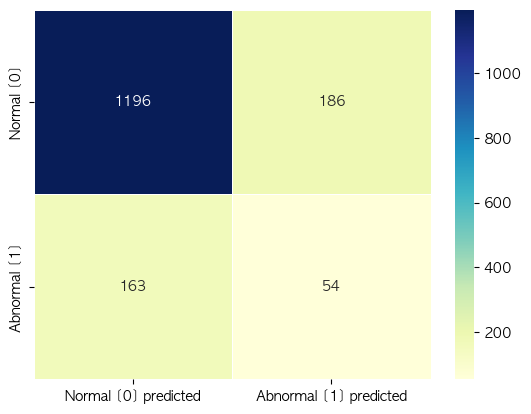

In [271]:
# 재구성 기반은 이상치는 다시 복구가 안될 것이다 라는 전제

# x_train 을 통해서 x_proj 를 계산, 이후에 threshold 설정
x_proj = pca.inverse_transform(pca.transform(x_train_sc))
recon_error = ( (x_train_sc - x_proj) **2 ).sum(axis=1)
recon_error = pd.DataFrame(recon_error,columns=['error']).sort_values(by='error',ascending=False)
thre = np.percentile(recon_error, 90)

x_proj = pca.inverse_transform(pca.transform(x_test_sc))
recon_error = ( (x_test_sc - x_proj) **2 ).sum(axis=1)
pred_pca = (recon_error >= thre).astype(int)

print(classification_report(y_test, pred_pca, digits=3))

cm_pca = confusion_matrix(y_test, pred_pca)

sns.heatmap(pd.DataFrame(cm, columns = ['normal [0]', 'abnormal [1]']),
            xticklabels=['Normal [0] predicted', 'Abnormal [1] predicted'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")

In [272]:
print(recon_error,'\n')
print("임계값:",thre)

0      1.919789
1      3.273779
2      6.668091
3      2.715196
4      1.046948
         ...   
315    2.283105
316    7.817010
317    3.163388
318    3.240231
319    7.112643
Length: 320, dtype: float64 

임계값: 10.389280803380524


EER : 0.4468


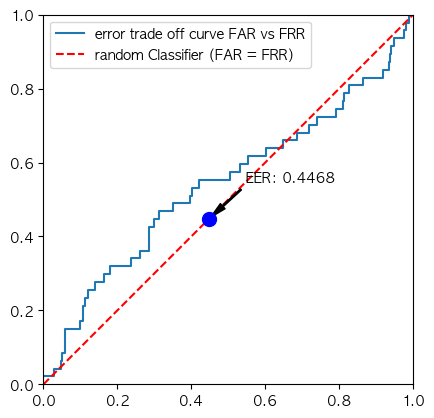

In [273]:
score(y_test, recon_error)

In [274]:
pred_index = pred_pca[pred_pca==1].index
true_index = y_test[y_test==1].index

true_index.isin(pred_index).sum()

np.int64(2)

In [275]:
pred_pca

0      0
1      0
2      0
3      0
4      0
      ..
315    0
316    0
317    0
318    0
319    0
Length: 320, dtype: int64

# KNN

In [276]:
knn = KNeighborsClassifier(n_neighbors=5, weights='uniform', algorithm='auto', metric='minkowski')
knn.fit(x_train_sc, y_train)

KNeighborsClassifier()

In [277]:
knn_pred_train = knn.predict(x_train_sc)
knn_pred_test = knn.predict(x_test_sc)

knn_pred_test_prob = knn.predict_proba(x_test_sc)[:,1]

print(metrics.accuracy_score(y_train, knn_pred_train))
print(metrics.accuracy_score(y_test, knn_pred_test))

print(classification_report(y_test, knn_pred_test, digits=3))

0.9124315871774824
0.88125
              precision    recall  f1-score   support

           0      0.907     0.960     0.932       273
           1      0.645     0.426     0.513        47

    accuracy                          0.881       320
   macro avg      0.776     0.693     0.723       320
weighted avg      0.868     0.881     0.871       320



[[262  11]
 [ 27  20]]


<Axes: >

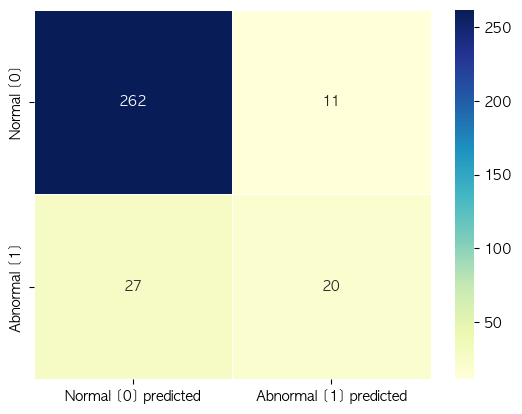

In [278]:
cm_knn = confusion_matrix(y_test, knn_pred_test)

# col : 모델 예측 
# raw : 실제
print(cm_knn)

sns.heatmap(pd.DataFrame(cm_knn, columns = ['normal [0]', 'abnormal [1]']),
            xticklabels=['Normal [0] predicted', 'Abnormal [1] predicted'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")

EER : 0.2170


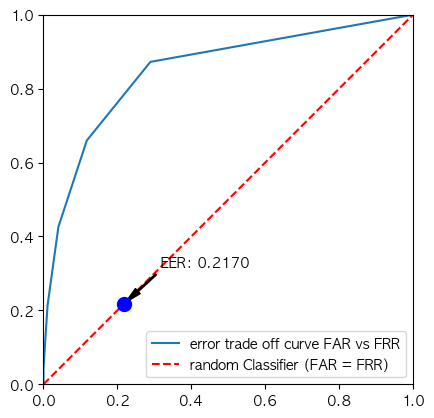

In [279]:
score(y_test, knn_pred_test_prob)

# KMeans

In [280]:
ssd = []
for num in range(2, 11):
    km = KMeans(n_clusters=num, init='k-means++', random_state=42, n_init=10)
    km.fit(x_train_sc)
    ssd.append(km.inertia_)

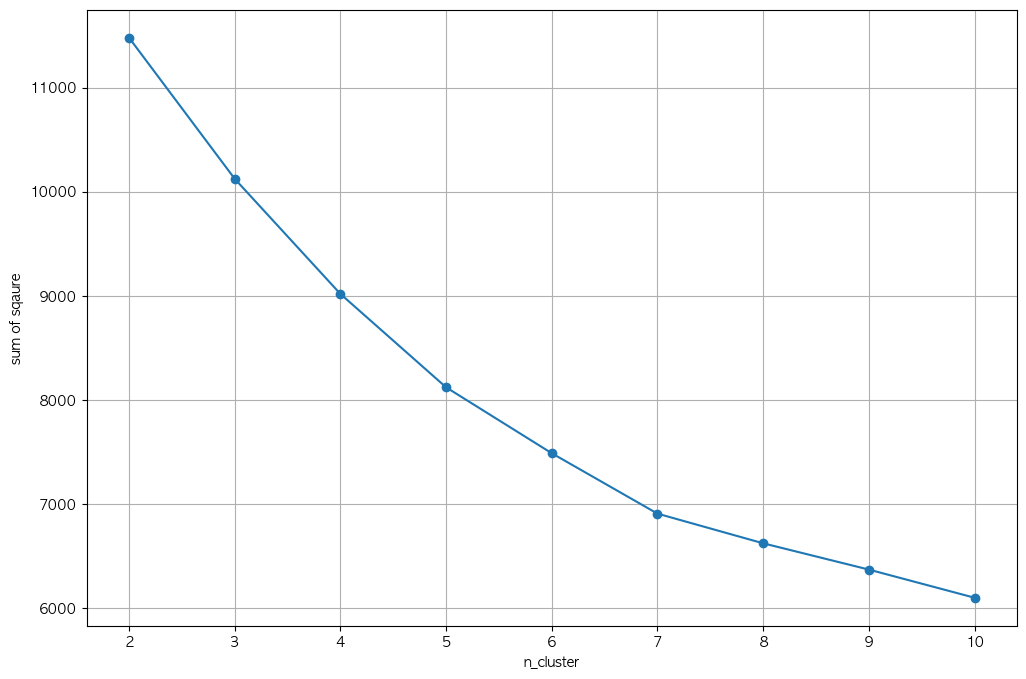

In [281]:
plt.figure(figsize=(12,8))
plt.plot(range(2,11), ssd, marker='o')
plt.xlabel('n_cluster')
plt.ylabel('sum of sqaure')
plt.xticks(range(2,11))
plt.grid()
plt.show()

In [282]:
km = KMeans(n_clusters=5)
km.fit(x_train)

KMeans(n_clusters=5)

In [283]:
def distance_from_center(input_data:pd.DataFrame, predict:pd.DataFrame, y):
    center = km.cluster_centers_[predict]
    dist = ((center-input_data)**2).sum(axis=1) # center 와 input_data 빼고 제곱하고 
    return np.round(dist, 3)

In [284]:
y_pred_train = km.predict(x_train)
dist_train = distance_from_center(x_train, y_pred_train, y_test)

km_x_train = x_train.copy()
km_x_train.loc[:,'pred'] = y_pred_train # 예측 군집 할당
km_x_train.loc[:, 'dist'] = dist_train # 군집 중심과의 거리

y_pred_test = km.predict(x_test)
dist_test = distance_from_center(x_test, y_pred_test, y_test)

km_x_test = x_test.copy()
km_x_test.loc[:,'dist'] = dist_test
km_x_test.loc[:,'pred'] = y_pred_test

In [285]:
# 24개 test data 에 대해 3개 이상치 데이터로 선정
#outlier_idx = list(x_test.sort_values('dist',ascending=False).head(10).index)

# 2nd way, set the threshold
# threshold = np.percentile(x_test['dist'], 90)

threshold = np.percentile(km_x_train['dist'], 90)
print(threshold)

out_lier = km_x_test[km_x_test['dist'] > threshold]

232.38640000000024


In [286]:
out_lier.index

Index([ 247,   23,   32,  184, 1054,  411,  526,  649,  240,  926,  109,  306,
       1389,  678,  905,  711, 1079,  353,  614,   78, 1167,  584,   15,  982,
        634,  332, 1529,  425, 1244,  192, 1175, 1295],
      dtype='int64')

In [287]:
y_pred_test = pd.DataFrame(y_pred_test, index=x_test.index)
y_pred_test.loc[out_lier.index] = 1
y_pred_test.loc[out_lier.index]

,0
247,1
23,1
32,1
184,1
1054,1
411,1
526,1
649,1
240,1
926,1


In [288]:
not_out_lier_idx= ~y_pred_test.index.isin(out_lier.index)
y_pred_test.loc[not_out_lier_idx] = 0

In [289]:
print(len(y_pred_test))
print(len(out_lier.index))
print(not_out_lier_idx.sum())

320
32
288


              precision    recall  f1-score   support

           0       0.90      0.85      0.87       288
           1       0.09      0.12      0.10        32

    accuracy                           0.78       320
   macro avg       0.49      0.49      0.49       320
weighted avg       0.82      0.78      0.80       320



<Axes: >

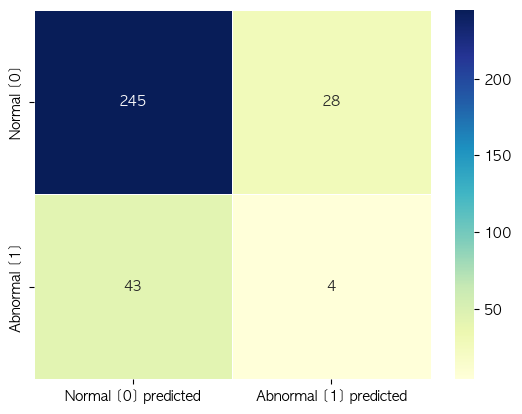

In [290]:
print(classification_report(y_pred_test, y_test))

# dist 가 threshold 보다 큰 outlier 데이터에 대한
# model predict 결과와
# 실제 y_test 
cm_kmeans = confusion_matrix(y_true=y_test, y_pred=y_pred_test)


sns.heatmap(pd.DataFrame(cm_kmeans, columns = ['normal [0]', 'abnormal [1]']),
            xticklabels=['Normal [0] predicted', 'Abnormal [1] predicted'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")

EER : 0.5106


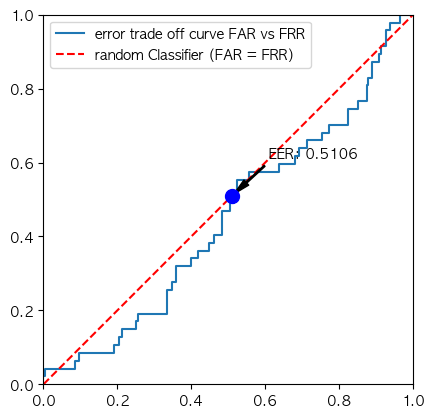

In [291]:
score(y_test, dist_test)

# GMM

- bic 를 통해 모델이 데이터를 얼마나 설명하는가를 판단
- covariance type 을 통해서 공분산 행렬의 형태를 가정 → 이를 통해, mixture 하는 가우시안 분포들이 어떻게 생겼는가를 가정
     - spherical : 모든 공분산이 같은 모양 같은 크기
     - diagonal : 공분산행렬이 대각행렬만 존재, 클러스터의 크기가 다를 수 있음
     - tied : 모양 크기 방향이 같지면 타원형일 수 있음
     - full : 자유자재

In [292]:
from sklearn.mixture import GaussianMixture
best_bic = np.inf
bic = []
cov_type = ["spherical", "diag", "tied", "full"]
n_components_range = range(2,11)

for type in cov_type:
    for n_components in n_components_range:
        mog = GaussianMixture(
            n_components=n_components, covariance_type=type, random_state=42
        )
        mog.fit(x_train_sc)
        bic.append(mog.bic(x_train_sc))
        if bic[-1] < best_bic:
            best_bic = bic[-1]
            best_mog = mog

In [293]:
print(best_mog.covariance_type)
print(best_mog.n_components)

full
5


In [294]:
mog_range = best_mog.n_components

In [295]:
range(mog_range)
range_map = {k : 0 for k in range(mog_range-1)}
range_map[mog_range-1] = 1
range_map

{0: 0, 1: 0, 2: 0, 3: 0, 4: 1}

In [296]:
mog_test_pred = best_mog.predict(x_test_sc)
mog_test_pred = pd.DataFrame(mog_test_pred)
mog_test_pred = mog_test_pred.replace(range_map)

mog_train_pred = best_mog.predict(x_train_sc)
mog_train_pred = pd.DataFrame(mog_train_pred)
mog_train_pred = mog_train_pred.replace(range_map)

In [297]:
mog_train_pred.value_counts()

0
0    995
1    284
Name: count, dtype: int64

In [298]:
mog_metric = y_train.copy()
mog_metric = mog_metric.reset_index()
mog_metric = pd.DataFrame(mog_metric)
mog_metric['mog_pred'] = mog_train_pred

# recall
print(len(mog_metric[(mog_metric['quality'] ==1) & (mog_metric['mog_pred'] ==1)]))
print("--")
print(mog_metric['quality'].value_counts()[1], '\n')

print(len(mog_metric[(mog_metric['quality'] ==0) & (mog_metric['mog_pred'] ==0)]))
print("--")
print(mog_metric['quality'].value_counts()[0])

2
--
170 

827
--
1109


In [299]:
mog_metric = y_test.copy()
mog_metric = mog_metric.reset_index()
mog_metric = pd.DataFrame(mog_metric)
mog_metric['mog_pred'] = mog_test_pred

print(len(mog_metric[(mog_metric['quality'] ==1) & (mog_metric['mog_pred'] ==1)]))
print("--")
print(mog_metric['quality'].value_counts()[1])

1
--
47


              precision    recall  f1-score   support

           0      0.823     0.784     0.803       273
           1      0.017     0.021     0.019        47

    accuracy                          0.672       320
   macro avg      0.420     0.403     0.411       320
weighted avg      0.705     0.672     0.688       320



Text(0.5, 23.52222222222222, 'Predicted')

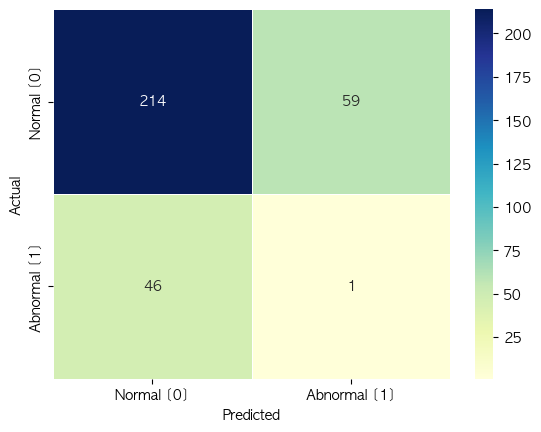

In [300]:
from sklearn.metrics import f1_score, recall_score, roc_auc_score

print(classification_report(y_true=mog_metric['quality'], y_pred=mog_metric['mog_pred'], digits=3))

cm_gmm = confusion_matrix(mog_metric['quality'], mog_metric['mog_pred'])

sns.heatmap(pd.DataFrame(cm_gmm, columns = ['Predicted', 'Actual']),
            xticklabels=['Normal [0]', 'Abnormal [1]'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")
plt.ylabel('Actual')
plt.xlabel('Predicted')

EER : 0.7656


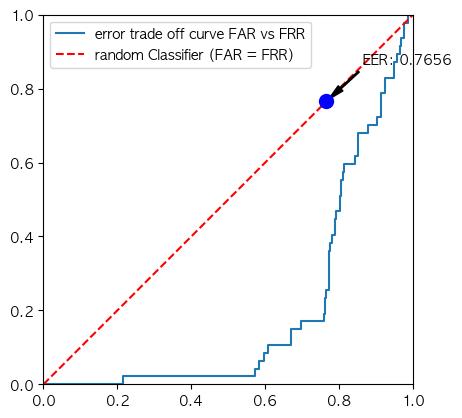

In [301]:
y_pred_mog_proba = best_mog.predict_proba(x_test_sc)[:,-1]
score(y_test, y_pred_mog_proba)

# IForest

In [302]:
from sklearn.ensemble import IsolationForest

In [303]:
isol = IsolationForest(contamination=0.1, random_state=42)
isol.fit(X=x_train, y=y_train)

IsolationForest(contamination=0.1, random_state=42)

              precision    recall  f1-score   support

           0       0.87      0.90      0.88       273
           1       0.25      0.19      0.22        47

    accuracy                           0.80       320
   macro avg       0.56      0.55      0.55       320
weighted avg       0.78      0.80      0.79       320



Text(0.5, 23.52222222222222, 'Predicted')

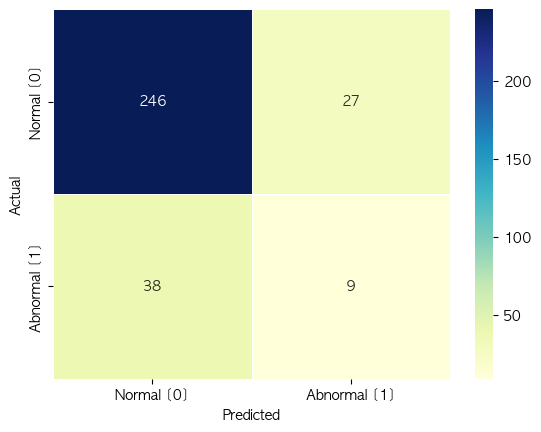

In [304]:
# -1 : anomaly
# 1 : normal
isol_pred_test = isol.predict(x_test)
isol_pred_test = pd.DataFrame(isol_pred_test)
isol_pred_test = isol_pred_test.replace({1:0, -1:1})

print(classification_report(y_true = y_test, y_pred = isol_pred_test))

cm_isol = confusion_matrix(y_test, isol_pred_test)
sns.heatmap(pd.DataFrame(cm_isol, columns = ['Predicted', 'Actual']),
            xticklabels=['Normal [0]', 'Abnormal [1]'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")
plt.ylabel('Actual')
plt.xlabel('Predicted')

EER : 0.4432


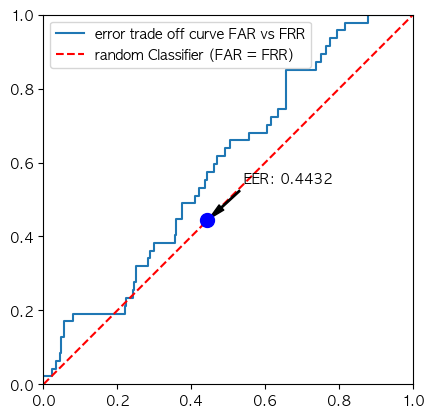

In [305]:
score(y_test, -isol.decision_function(x_test))

# LoF

In [306]:
from sklearn.neighbors import LocalOutlierFactor

              precision    recall  f1-score   support

           0       0.88      0.87      0.87      1382
           1       0.23      0.25      0.24       217

    accuracy                           0.78      1599
   macro avg       0.55      0.56      0.55      1599
weighted avg       0.79      0.78      0.79      1599



Text(0.5, 23.52222222222222, 'Predicted')

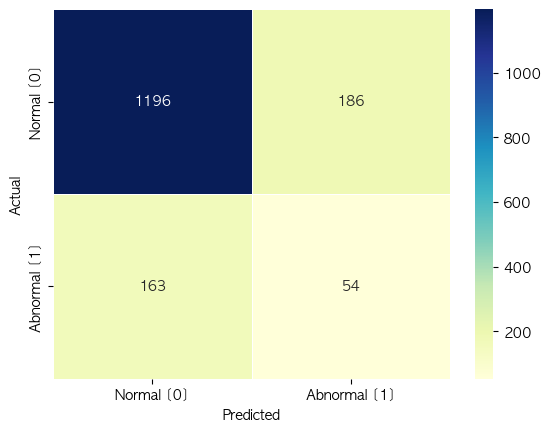

In [ ]:
lof = LocalOutlierFactor(novelty=False, n_neighbors=20, algorithm='auto',contamination=0.15)

result = lof.fit_predict(X=over_sampled_x, y=over_sampled_y) # y doesnt use in fitting procedure

result = pd.DataFrame(result)
result = result.replace({1:0, -1:1})

print(classification_report(y_true = over_sampled_y, y_pred = result))

cm_lof = confusion_matrix(y_true= over_sampled_y, y_pred = result)
sns.heatmap(pd.DataFrame(cm_lof, columns = ['Predicted', 'Actual']),
            xticklabels=['Normal [0]', 'Abnormal [1]'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")
plt.ylabel('Actual')
plt.xlabel('Predicted')

EER : 0.5991


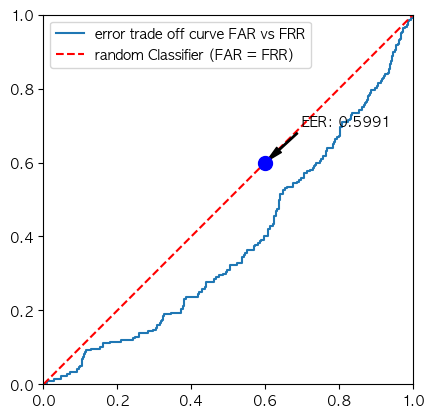

In [350]:
lof.fit(X=over_sampled_x, y=over_sampled_y)
lof_score = lof.negative_outlier_factor_

score(over_sampled_y, lof_score)

# Auto Encoder

In [ ]:
import torch
import torch.nn as nn
import torch.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import Dataset


class AutoEncoder(nn.Module):
    def __init__(self, input_dim, **kwargs):
        super(AutoEncoder,self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.ReLU(),
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )
        self.decoder = nn.Sequential(
            nn.Linear(1, 4),
            nn.ReLU(),
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim),
            nn.ReLU(),
            nn.Linear(input_dim, input_dim)
        )
    def forward(self, x):
        x = self.encoder(x)
        out = self.decoder(x)
        return out

class WineDataset(Dataset):
    def __init__(self, input:pd.DataFrame, target:pd.DataFrame):
        self.input = torch.tensor(input.values, dtype=torch.float32)
        self.target = torch.tensor(target.values, dtype=torch.float32)
        
    def __len__(self):
        return len(self.input)
    def __getitem__(self, index):
        return self.input[index], self.target[index]

In [309]:
model_config={
    "input_dim" : len(x_train_sc.columns),
    "batch_size" : 16,
    "lr" : 1e-3,
    "loss" : nn.MSELoss(),
    "epoch" : 150
}

train_dataset = WineDataset(x_train_sc, y_train)
test_dataset = WineDataset(x_test_sc, y_test)

train_loader = DataLoader(
    dataset = train_dataset,
    batch_size = model_config['batch_size'],
    shuffle=True
)

test_loader = DataLoader(
    dataset = test_dataset,
    batch_size = model_config['batch_size'],
    shuffle=True
)

model = AutoEncoder(input_dim=model_config['input_dim'])

criterion = model_config["loss"]
optimizer = optim.Adam(model.parameters(), lr=model_config["lr"])

device = torch.device('cpu')

train_losses = []
test_losses = []

for epoch in range(model_config['epoch']):
    model.train()
    train_loss = 0
    test_loss = 0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
    train_epoch_loss = train_loss / len(train_dataset)
    train_losses.append(train_epoch_loss)
    
    with torch.no_grad():    
        model.eval()
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            test_loss += loss.item() * inputs.size(0)
        test_epoch_loss = test_loss / len(test_dataset)
        test_losses.append(test_epoch_loss)
        
    print(f"Epoch [{epoch+1}/{model_config['epoch']}] completed. [Train] Average Loss: {train_epoch_loss:.4f} , [Test] Average Loss : {test_epoch_loss:.4f}")


In [310]:
from tqdm import tqdm

# recent value 
# \*모든 클래스의 조상인 object 클래스
class AverageMeter(object):
    def __init__(self):
        self.reset()
    def reset(self):
        self.avg = 0
        self.val = 0
        self.sum = 0
        self.count = 0
    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def compute_mse(pred,target):
    pass

In [311]:
def train(model_config, dataset, criterion):
    device = torch.device('cpu')
    train_loader = DataLoader(dataset=dataset[0],batch_size=model_config['batch_size'],shuffle=False, drop_last=True)
    test_loader = DataLoader(dataset=dataset[1],batch_size=model_config['batch_size'],shuffle=False, drop_last=True)
    
    model = AutoEncoder(input_dim=model_config['input_dim'])
    model.to(device)
    
    optimizer=optim.Adam(model.parameters(), lr=model_config['lr'])
    
    train_loss, test_loss = AverageMeter(), AverageMeter()
    train_loss_list, test_loss_list = [], []
    best_loss = 0
    
    for epoch in range(1, model_config['epoch']):
        model.train()
        train_bar = tqdm(train_loader) #visualize repeatation part
        train_loss.reset()
        for inputs, targets in train_bar:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            pred = model(inputs)
            loss = criterion(pred, inputs) # audoencoder calculate loss using inputs & pred
            loss.backward()
            optimizer.step()
            train_loss.update(loss.item(), model_config['batch_size'])
            train_bar.set_description(desc=f"{epoch}/{model_config['epoch']} [train] Loss : {train_loss.avg:.6f}")
        train_loss_list.append(train_loss.avg)
    
        test_bar = tqdm(test_loader)
        test_loss.reset()
    
        for inputs, targets in test_bar:
            inputs, targets = inputs.to(device), targets.to(device)
            model.eval()
            with torch.no_grad():
                pred = model(inputs)
                loss = criterion(pred, inputs)
                test_loss.update(loss.item(), model_config['batch_size'])
                test_bar.set_description(desc=f"{epoch}/{model_config['epoch']} [test] Loss : {test_loss.avg:.6f}")
        test_loss_list.append(test_loss.avg)
    return train_loss_list, test_loss_list

In [312]:
train_loss_list, test_loss_list = train(model_config, [train_dataset, test_dataset], criterion=criterion)

149/150 [test] Loss : 0.522210: 100%|██████████| 20/20 [00:00<00:00, 1065.87it/s]


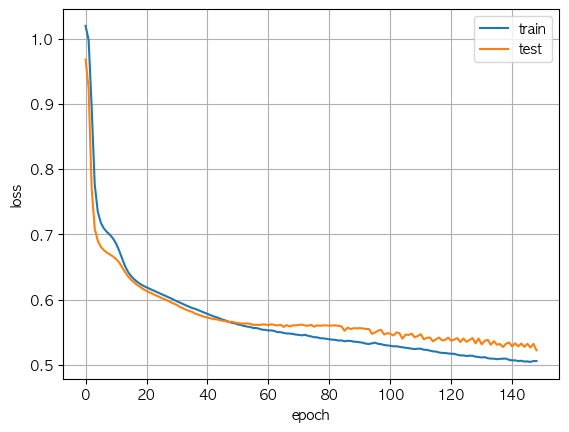

In [313]:
plt.plot(train_loss_list, label='train')
plt.plot(test_loss_list, label='test')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid()

In [314]:
model.eval()

ae_train_pred = model(torch.tensor(x_train_sc.values, dtype=torch.float32))

train_mse = np.mean(np.power(ae_train_pred.detach().numpy() - x_train_sc, 2), axis=1)
threshold = np.percentile( sorted(train_mse), 90)

ae_test_pred = model(torch.tensor(x_test_sc.values, dtype=torch.float32))
test_mse = np.mean(np.power(ae_test_pred.detach().numpy() - x_test_sc, 2), axis=1)


              precision    recall  f1-score   support

           0       0.85      0.90      0.87       273
           1       0.12      0.09      0.10        47

    accuracy                           0.78       320
   macro avg       0.49      0.49      0.49       320
weighted avg       0.74      0.78      0.76       320



<Axes: >

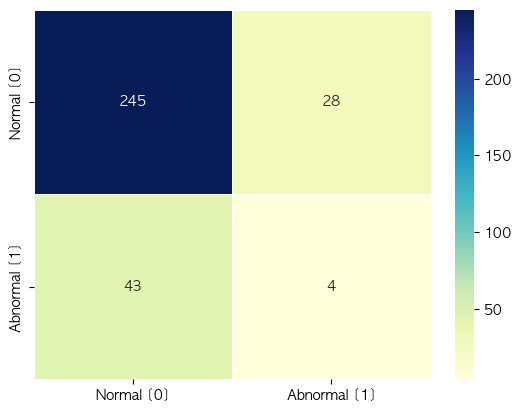

In [315]:
outlier_idx = test_mse[test_mse > threshold].index
ae_y_pred = y_test.copy()
ae_y_pred = pd.DataFrame(ae_y_pred)
ae_y_pred['pred'] = 0
ae_y_pred.loc[out_lier.index, 'pred'] = 1

print(classification_report(y_true=ae_y_pred['quality'],y_pred=ae_y_pred['pred']))

cm_ae = confusion_matrix(y_true=ae_y_pred['quality'],y_pred=ae_y_pred['pred'])
sns.heatmap(pd.DataFrame(cm_ae, columns = ['Predicted', 'Actual']),
            xticklabels=['Normal [0]', 'Abnormal [1]'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")

EER : 0.4255


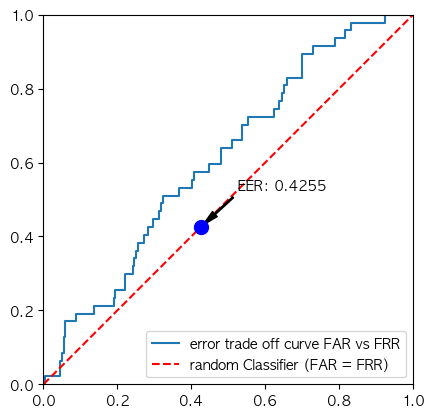

In [316]:
score(y_test, test_mse)

# My pick : One class SVM

In [317]:
print(y.value_counts())

x_train, x_test, y_train, y_test = train_test_split(over_sampled_x, over_sampled_y , test_size=0.2, random_state=42)

quality
0    1382
1     217
Name: count, dtype: int64


In [318]:
from sklearn.svm import OneClassSVM

sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

oc_svm = OneClassSVM(kernel='rbf', nu=0.2)
oc_svm.fit(x_train_sc)

y_pred_svm = oc_svm.predict(x_test_sc) # 정상 1, 이상치 -1


In [319]:
y_pred_svm[y_pred_svm == 1] = 0
y_pred_svm[y_pred_svm == -1] = 1
y_pred_svm

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,

              precision    recall  f1-score   support

           0      0.866     0.806     0.835       273
           1      0.197     0.277     0.230        47

    accuracy                          0.728       320
   macro avg      0.532     0.541     0.533       320
weighted avg      0.768     0.728     0.746       320



Text(50.722222222222214, 0.5, 'actual')

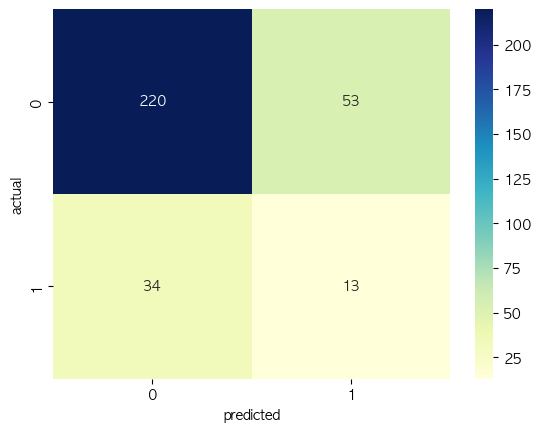

In [320]:
print(classification_report(y_true = y_test, y_pred=y_pred_svm, digits=3))

cm_ocsvm = confusion_matrix(y_true = y_test, y_pred=y_pred_svm)

sns.heatmap(cm_ocsvm, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel('predicted')
plt.ylabel('actual')

In [321]:
con_mat # row : actual , col : predicted

array([[244,  29],
       [ 44,   3]])

EER : 0.5314


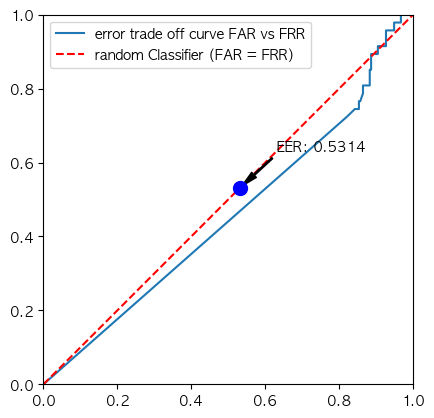

In [322]:
score(y_test,-oc_svm.decision_function(x_test))

# KNN's develop
- weighted knn

In [323]:
y_test.value_counts()

quality
0    273
1     47
Name: count, dtype: int64

In [ ]:
w_knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
w_knn.fit(x_train_sc, y_train)

y_pred_wknn = w_knn.predict(x_test_sc)

In [325]:
print(classification_report(y_true=y_test, y_pred=y_pred_wknn))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       273
           1       0.73      0.64      0.68        47

    accuracy                           0.91       320
   macro avg       0.84      0.80      0.82       320
weighted avg       0.91      0.91      0.91       320



Text(50.722222222222214, 0.5, 'actual')

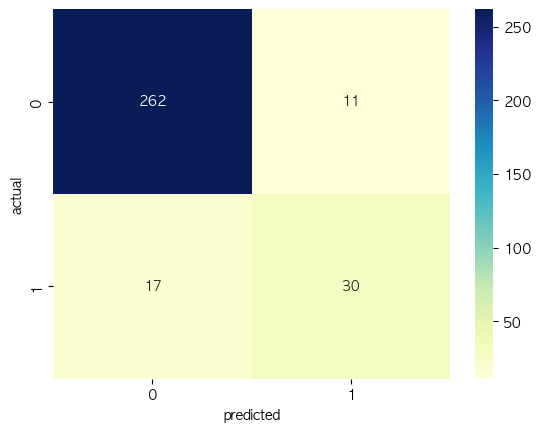

In [326]:
cm_wknn = confusion_matrix(y_true = y_test, y_pred=y_pred_wknn)

sns.heatmap(cm_wknn, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel('predicted')
plt.ylabel('actual')

EER : 0.1915


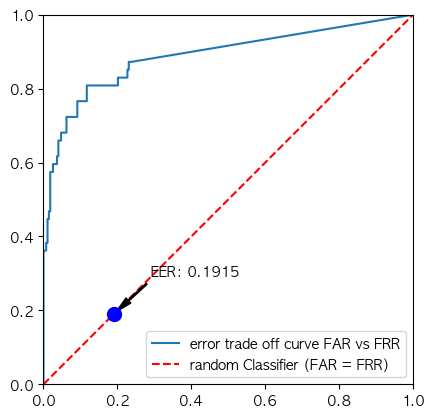

In [327]:
w_knn_proba =w_knn.predict_proba(x_test_sc)[:,1] 
score(y_test,w_knn_proba)

In [436]:
hyperparameter_grid = {
    "contamination": [0.1, 0.2, 0.3, 0.4], 
    "n_neighbors": list(range(5, 30, 5)),
    "algorithm": ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'metric': ['euclidean', 'manhattan', 'minkowski', 'chebyshev']
}

In [39]:
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from pyod.models.knn import KNN
from sklearn.metrics import make_scorer, f1_score 
import warnings
warnings.filterwarnings('ignore')
model = KNN() 


hyperparameter_grid = {
    "n_neighbors": list(range(5, 30, 5)), 
    "algorithm": ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'metric': ['euclidean', 'manhattan', 'minkowski', 'chebyshev'],
}

scorer = make_scorer(f1_score, pos_label=1) 

grid_search = GridSearchCV(
    estimator=model, 
    param_grid=hyperparameter_grid, 
    scoring=scorer,
    cv=5
)

grid_search.fit(x_train_sc, y_train)

GridSearchCV(cv=5,
             estimator=KNN(algorithm='auto', contamination=0.1, leaf_size=30, method='largest',
  metric='minkowski', metric_params=None, n_jobs=1, n_neighbors=5, p=2,
  radius=1.0),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'metric': ['euclidean', 'manhattan', 'minkowski',
                                    'chebyshev'],
                         'n_neighbors': [5, 10, 15, 20, 25]},
             scoring=make_scorer(f1_score, response_method='predict', pos_label=1))

In [41]:
print("최적의 파라미터:", grid_search.best_params_)
print("최고 F1-Score:", grid_search.best_score_)

최적의 파라미터: {'algorithm': 'auto', 'metric': 'euclidean', 'n_neighbors': 25}
최고 F1-Score: 0.14624201580136897


# ABOD (Angle Based Outlier Detection)
- normal 데이터는 군집내 다른 두점을 연결해 만들어진 각도 $\angle APB$ 의 분산이 클 것임 (서로서로 보여있으니깐)
- normal 군집에서 떨어진 outlier 는 비교적 각도의 분산이 작을 것임

In [2]:
from pyod.models.abod import ABOD

In [23]:
detector = ABOD(contamination=0.2,n_neighbors=10, method='default')
detector.fit(x_train)
pred_y_abod = detector.predict(x_test)

print(classification_report(y_test, pred_y_abod))
cm_abod = confusion_matrix(y_true = y_test, y_pred=pred_y_abod)

sns.heatmap(cm_abod, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel('predicted')
plt.ylabel('actual')

KeyboardInterrupt: 

EER : 0.6264


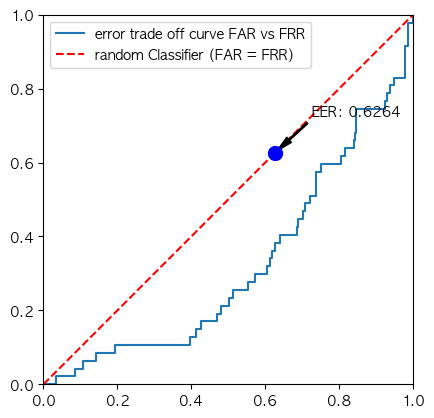

In [333]:
abod_proba = detector.predict_proba(x_test_sc)[:,1]
score(y_test, abod_proba)

In [354]:
y_pred_for_eer = [recon_error, knn_pred_test_prob, dist_test, y_pred_mog_proba, -isol.decision_function(x_test), lof_score, -oc_svm.decision_function(x_test), w_knn_proba, abod_proba, test_mse]
pred_str = ['PCA', 'KNN', 'KMeans', 'Mog', 'Isol', 'lof', 'OneClassSVM', 'Weighted_KNN', 'ABOD', 'AutoEncoder']
#score(y_test,lambda x :y_pred_for_eer[i])

In [431]:
def score_list(y_true:np.ndarray, y_pred_list:list):
    plt.figure(figsize=(30,15))
    def plot(i):
        plt.subplot(2,5,i)
        plt.plot(FPR, TPR, label="error trade off curve FAR vs FRR")
        plt.plot([0,1], [0,1], 'r--', label="random Classifier (FAR = FRR)")
        plt.scatter(EER,EER, color='blue', s=100, zorder=5)
        plt.annotate(
            f"EER: {EER:.4f}",
            fontsize=20,
            xy=(EER,EER),
            xytext=(EER +0.1, EER+0.1),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5)
        )
        plt.legend()
        plt.xlim(0,1)
        plt.ylim(0,1)
        plt.gca().set_aspect('equal', adjustable='box')
        
    i = 1
    for y_pred in y_pred_list:
        if pred_str[i-1] == 'lof':
            FPR, TPR, threshold = roc_curve(over_sampled_y, y_pred, pos_label=1) # False Positive, True Positive
        else:
            FPR, TPR, threshold = roc_curve(y_true, y_pred, pos_label=1) # False Positive, True Positive
        FRR = 1 - TPR
        FAR = FPR
        EER = brentq(lambda x: 1. -x - interp1d(FPR, TPR)(x), 0., 1.)
        print(f"EER : {EER:.4f}")
        plot(i)
        plt.xlabel(pred_str[i-1], fontsize=20)
        i+=1
        
    plt.tight_layout()
    plt.show()
    

EER : 0.4468
EER : 0.2170
EER : 0.5106
EER : 0.7656
EER : 0.4432
EER : 0.5991
EER : 0.5314
EER : 0.1915
EER : 0.6264
EER : 0.4255


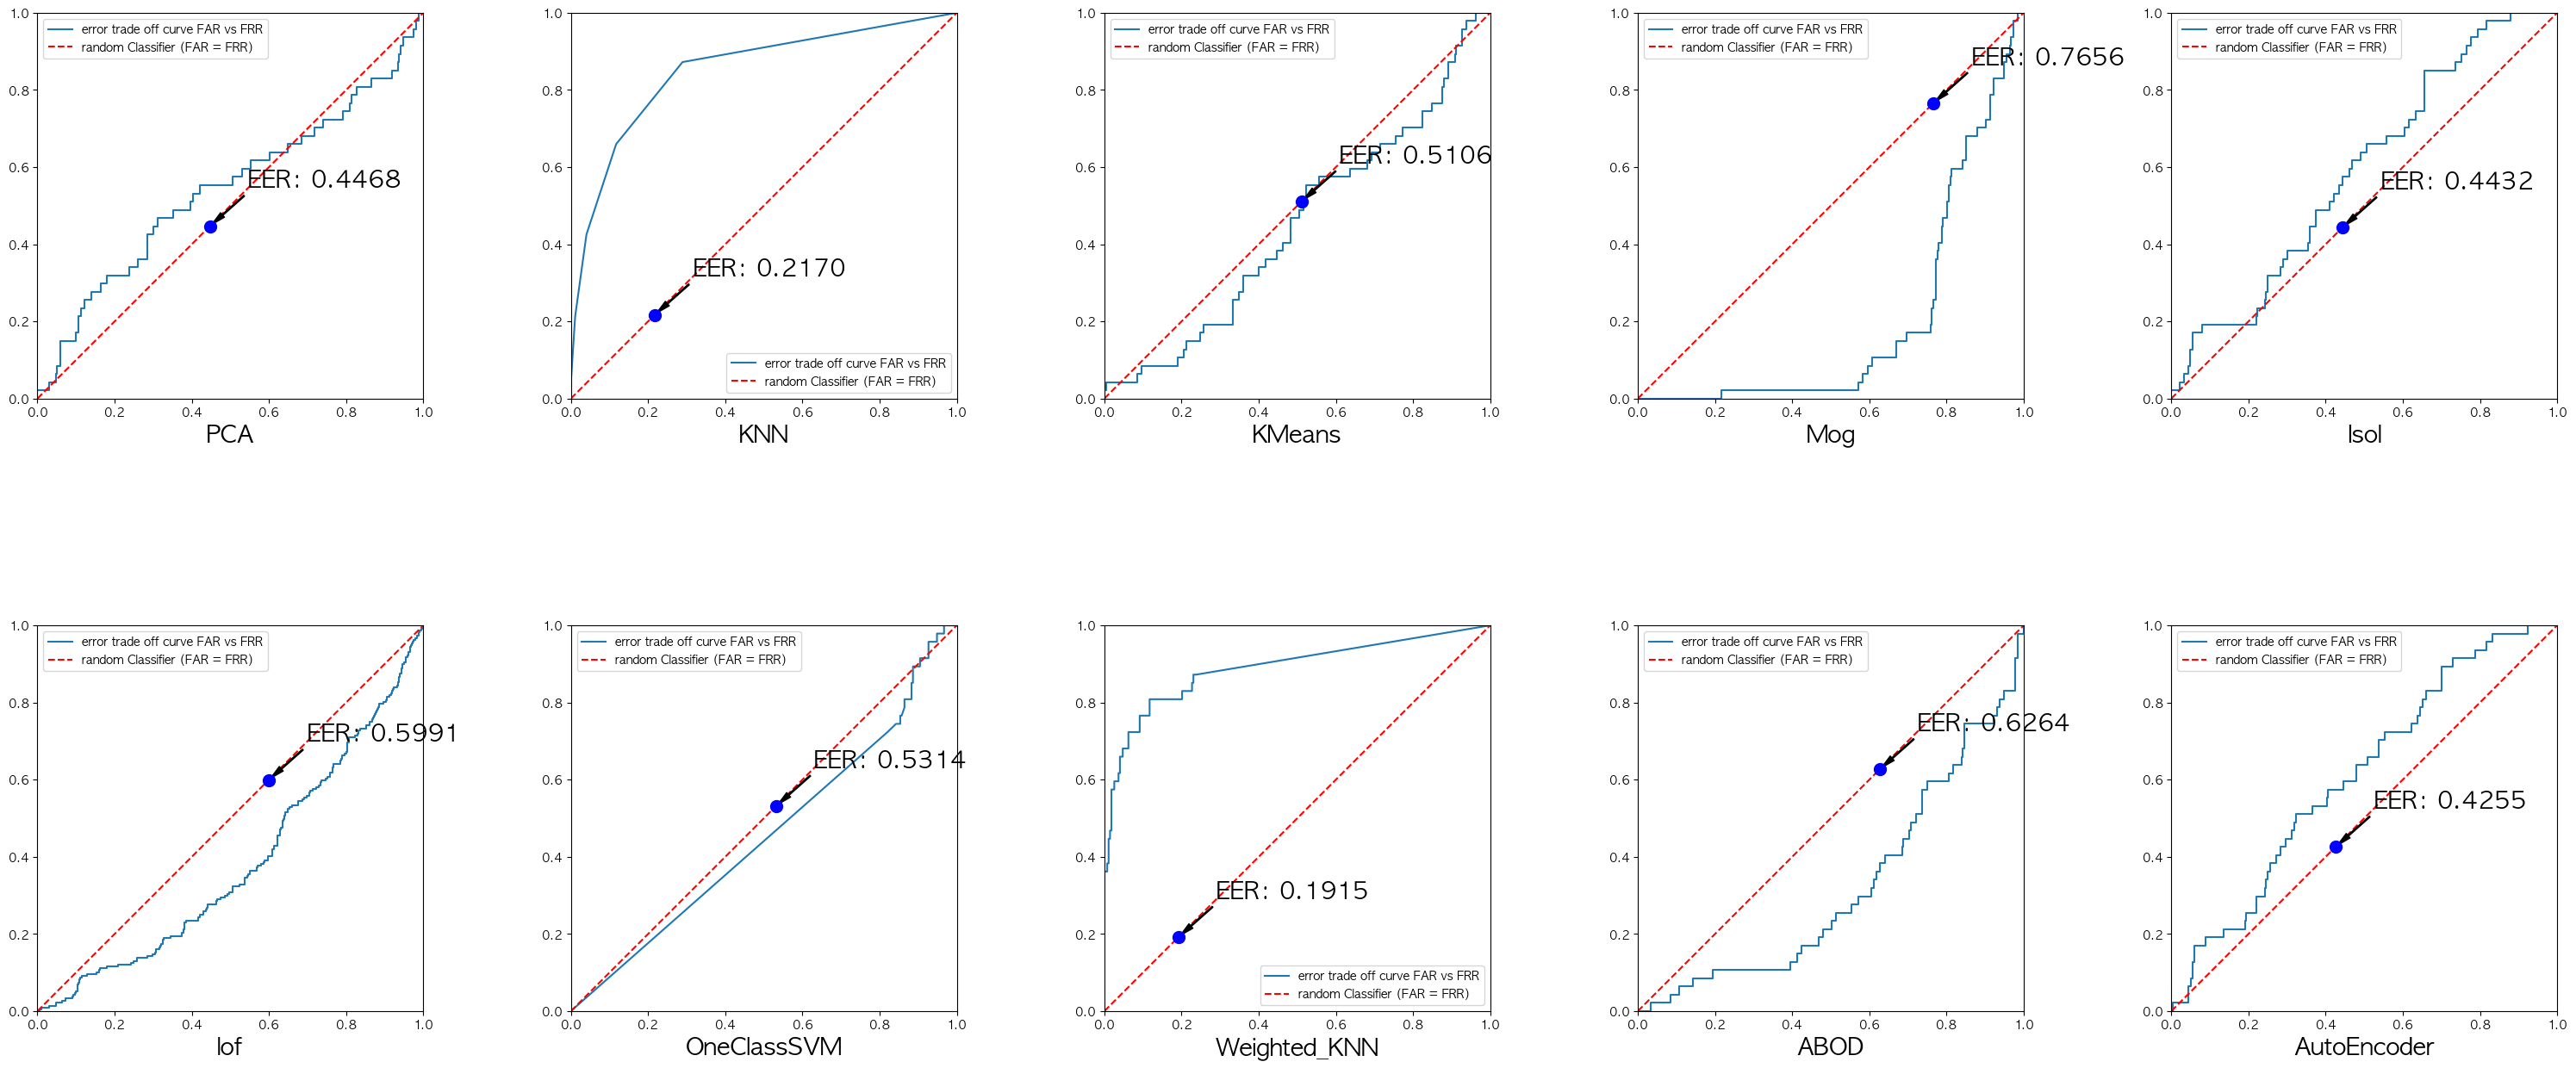

In [432]:
score_list(y_test, y_pred_for_eer)

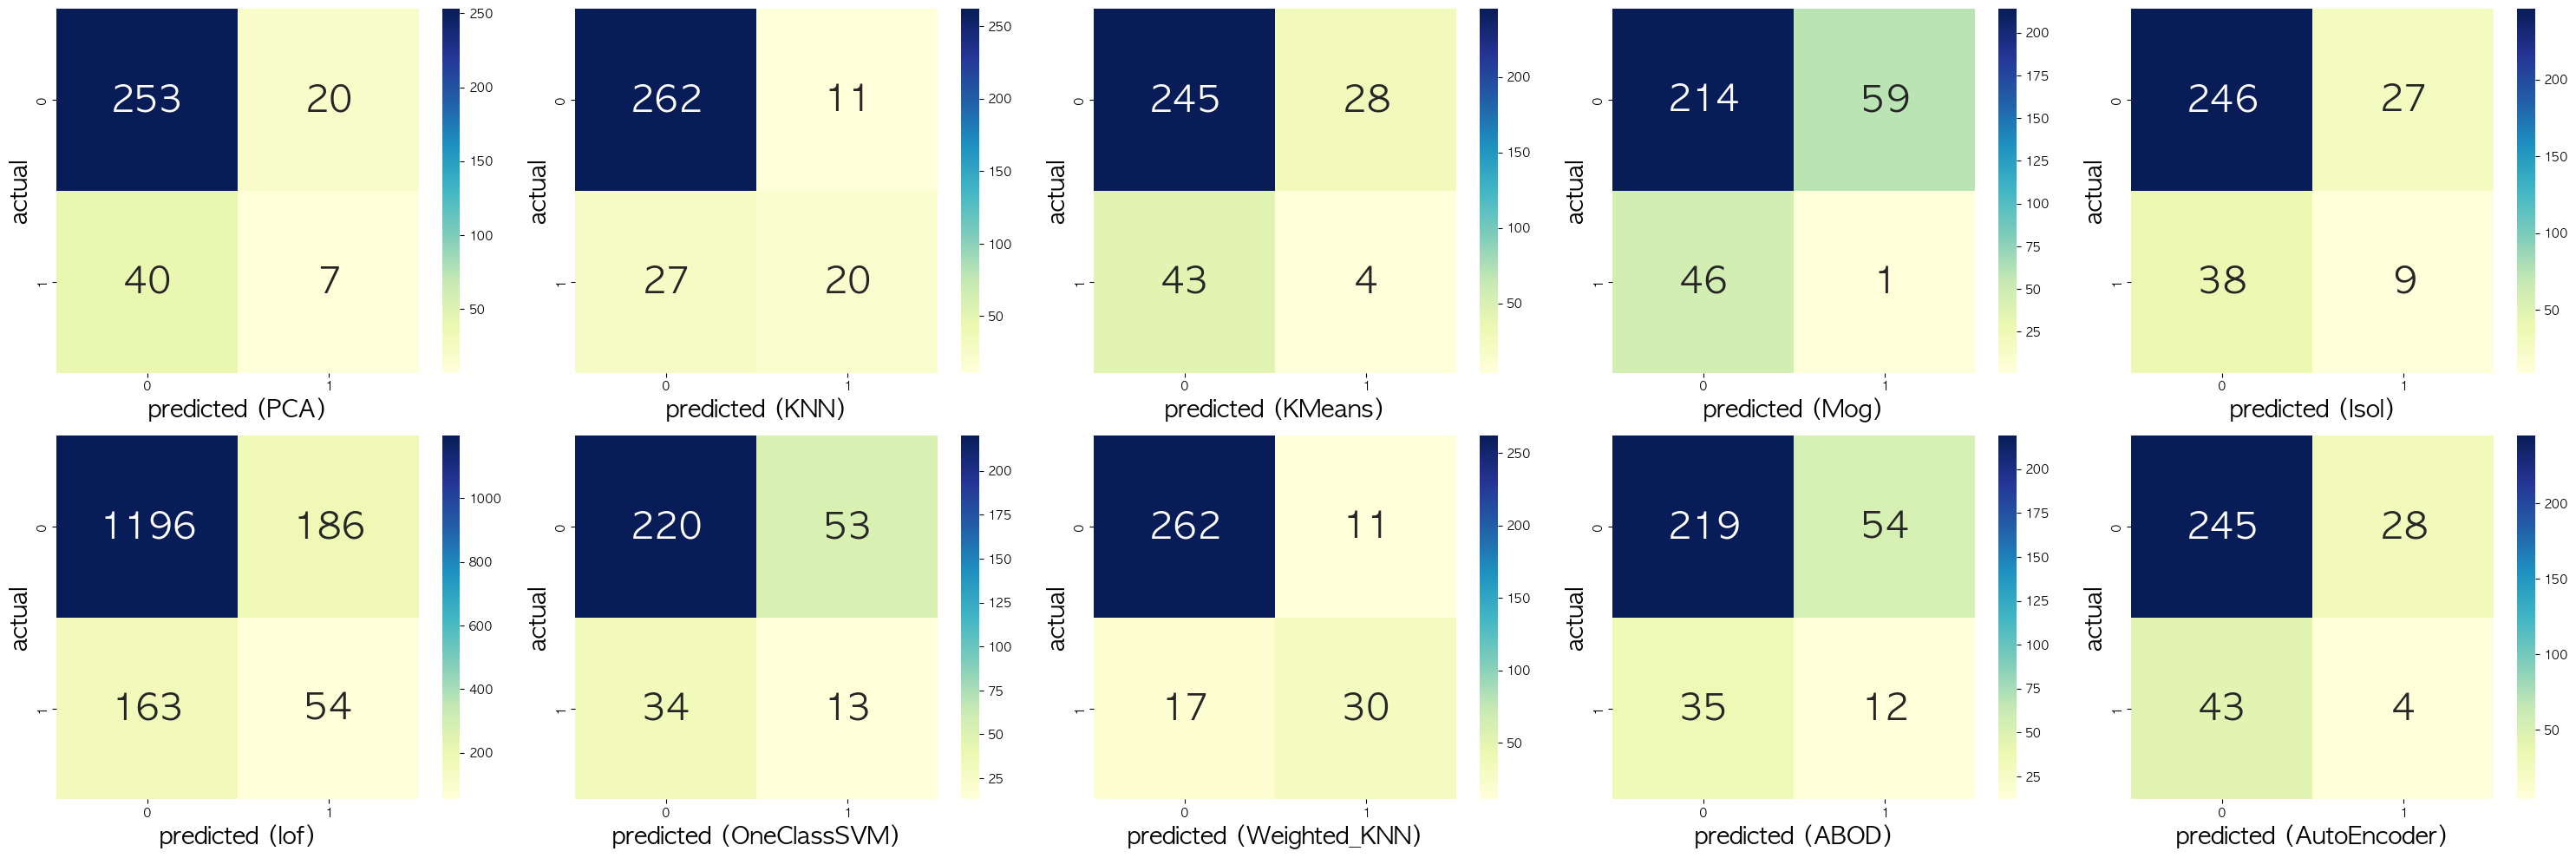

In [398]:
cms = [cm_pca, cm_knn, cm_kmeans, cm_gmm, cm_isol, cm_lof, cm_ocsvm, cm_wknn, cm_abod, cm_ae]
pred_str = ['PCA', 'KNN', 'KMeans', 'Mog', 'Isol', 'lof', 'OneClassSVM', 'Weighted_KNN', 'ABOD', 'AutoEncoder']

plt.figure(figsize=(30,10))
for idx, cm in enumerate(cms):
    plt.subplot(2,5,idx+1)
    sns.heatmap(cm, cmap='YlGnBu',annot=True, fmt='d', annot_kws={"size":30}) 
    plt.xlabel(f'predicted ({pred_str[idx]})', fontsize=20)
    plt.ylabel('actual', fontsize=20)
plt.tight_layout()
plt.show()

